# When is it Most Dangerous in Philly?

<img src="img/gunViolence.jpg" width="450" style="display:block; margin:auto;">

Gun violence is a very prominent issue in Philadelphia. With the city experiencing 826 shootings in 2025 it has one of the highest shooting rates across the country. Most of these shootings do occur in concentrated parts across the city but to ensure safety when going out, it is important to analyse the times of the day in which it is most common for shootings to occur. 

### Loading the Data

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [12]:
shootings_df = pd.read_csv('data/shootings.csv')
shootings_df.columns

Index(['the_geom', 'the_geom_webmercator', 'objectid', 'year', 'dc_key',
       'code', 'date_', 'time', 'race', 'sex', 'age', 'wound',
       'officer_involved', 'offender_injured', 'offender_deceased', 'location',
       'latino', 'point_x', 'point_y', 'dist', 'inside', 'outside', 'fatal',
       'lat', 'lng'],
      dtype='str')

While this dataset provides a comprehensive list of information about past shootings in Philadelphia, we will be focusing in specific on the columns regarding the date and times of shootings. 

This dataset spans from 2015-2026, including all recorded shootings during this time. Within this dataset, there are **17,516** total shootings with **20%** of them being fatal. 

### Parsing the Data

We will first process the data, parsing the format of the date time variables stored as well as breaking down the recorded times into their specific hours, days, months and years. 

In [14]:
shootings_df['date_'] = pd.to_datetime(shootings_df['date_'])
shootings_df['hour'] = pd.to_datetime(shootings_df['time'], format='%H:%M:%S').dt.hour
shootings_df['month'] = shootings_df['date_'].dt.month
shootings_df['month_name'] = shootings_df['date_'].dt.strftime('%b')
shootings_df['day_of_week'] = shootings_df['date_'].dt.day_name()
shootings_df['year'] = shootings_df['date_'].dt.year
shootings_df['fatal'] = shootings_df['fatal'].fillna(0).astype(int)

### Tracking Shootings by Year

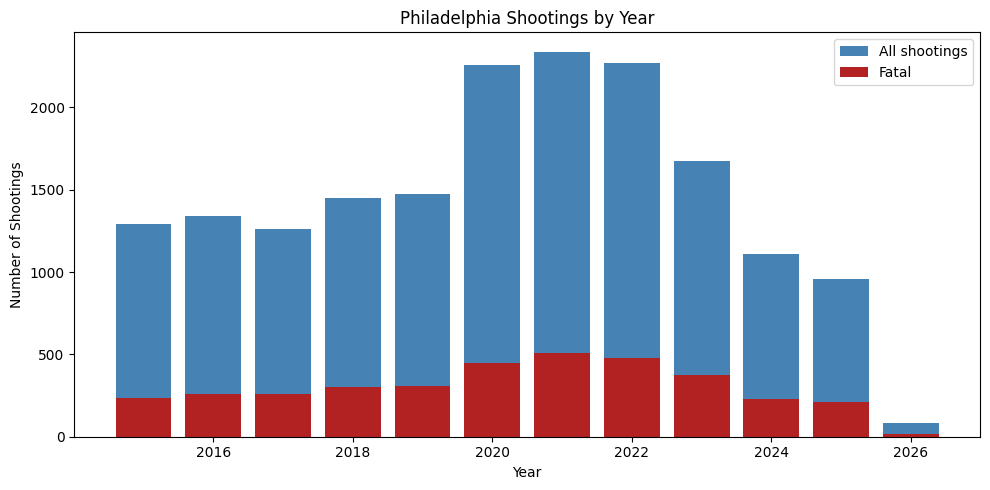

In [15]:
yearly = shootings_df.groupby('year').size()
yearly_fatal = shootings_df[shootings_df['fatal']==1].groupby('year').size()

plt.figure(figsize=(10, 5))
plt.bar(yearly.index, yearly.values, label='All shootings', color='steelblue')
plt.bar(yearly_fatal.index, yearly_fatal.values, label='Fatal', color='firebrick')
plt.title('Philadelphia Shootings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Shootings')
plt.legend()
plt.tight_layout()
plt.show()

From the chart above, we can observe a large increase in shootings between 2020 and 2022. This is the COVID period, where there were lockdowns, sickness and increased poverty. Such conditions are likely to have accentuated societal unrest where falling living conditions would have resulted in increased crime.

However, in recent years, the government has been working to reduce crime across Philadelphia where their efforts are reflected in the falling levels of gun violence.

### Shootings by Month

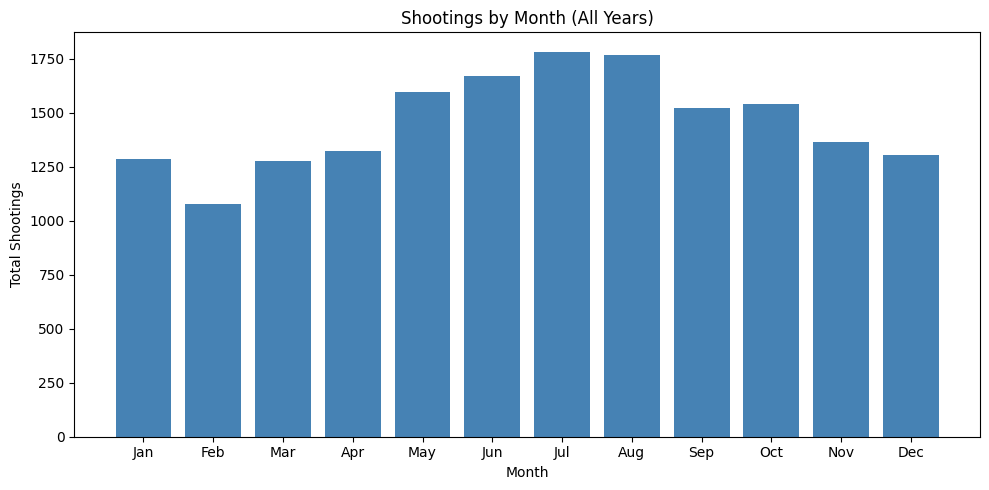

In [16]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = shootings_df.groupby('month_name').size().reindex(month_order)

plt.figure(figsize=(10, 5))
plt.bar(monthly.index, monthly.values, color='steelblue')
plt.title('Shootings by Month (All Years)')
plt.xlabel('Month')
plt.ylabel('Total Shootings')
plt.tight_layout()
plt.show()

In observing the number of shootings across Philadelphia in different months, we can observe a pattern relating to the seasons. The highest levels of shootings occur in summer, between June and August, falling steadily in the colder winter months until February where it starts to increase again.

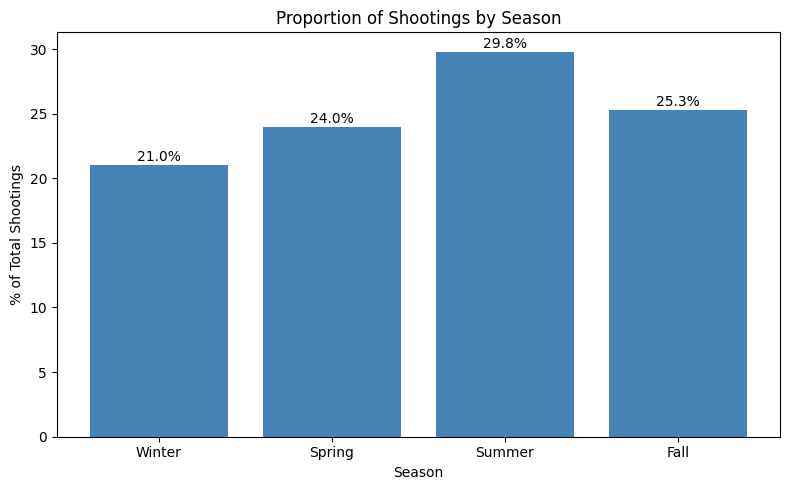

In [19]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_pct = season_pct.reindex(season_order)

plt.figure(figsize=(8, 5))
plt.bar(season_pct.index, season_pct.values, color='steelblue')
plt.title('Proportion of Shootings by Season')
plt.xlabel('Season')
plt.ylabel('% of Total Shootings')

for i, (season, val) in enumerate(season_pct.items()):
    plt.text(i, val + 0.3, f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

This chart better shows that trend where shootings are more likely in warmer months of the year. This can be attributed to the fact that in times of warmer and more comfortable weather, more people are likely to be in public spaces. This increases the chance of confrontation between individuals and thus increases the chance of shootings. 

### Shootings by Day and Hour

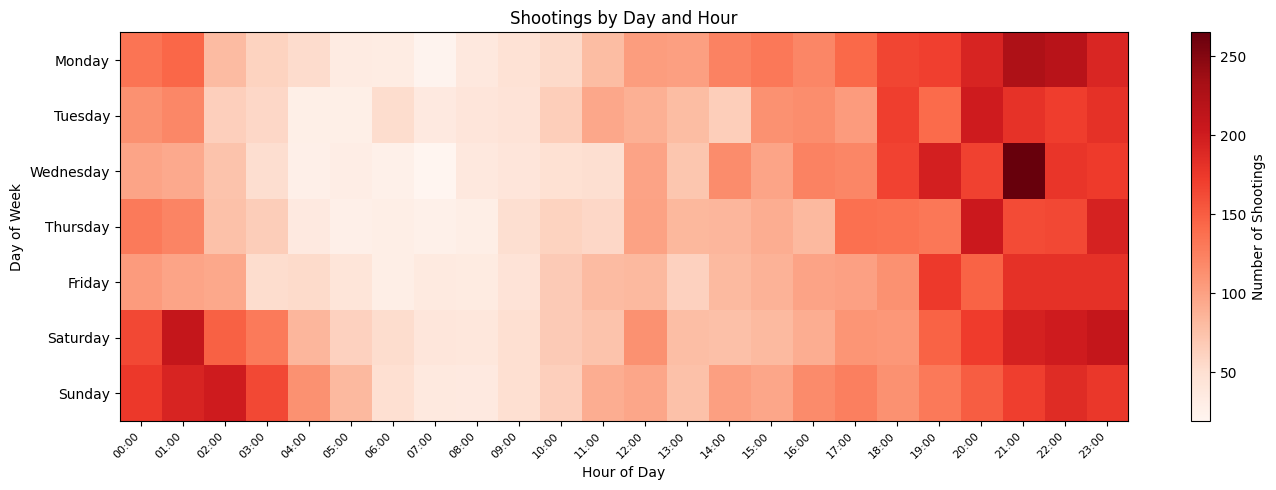

In [20]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = shootings_df.groupby(['day_of_week','hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_data.values, aspect='auto', cmap='Reds')
plt.colorbar(label='Number of Shootings')
plt.title('Shootings by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.xticks(range(24), [f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
plt.yticks(range(7), day_order)
plt.tight_layout()
plt.show()

Now which times would be the safest to go outside? In the heatmap above, it can be observed that most shootings happen late at night, between 7pm to 1am. Meanwhile, there are relatively few shootings in the early mornings between 5am and 11am and moderate levels in the afternoon between 11am and 6pm. 

As such, especially if travelling into a dangerous area, it would be recommended to go during the daytime.

### Fatal and Non Fatal Shootings by Time of Day

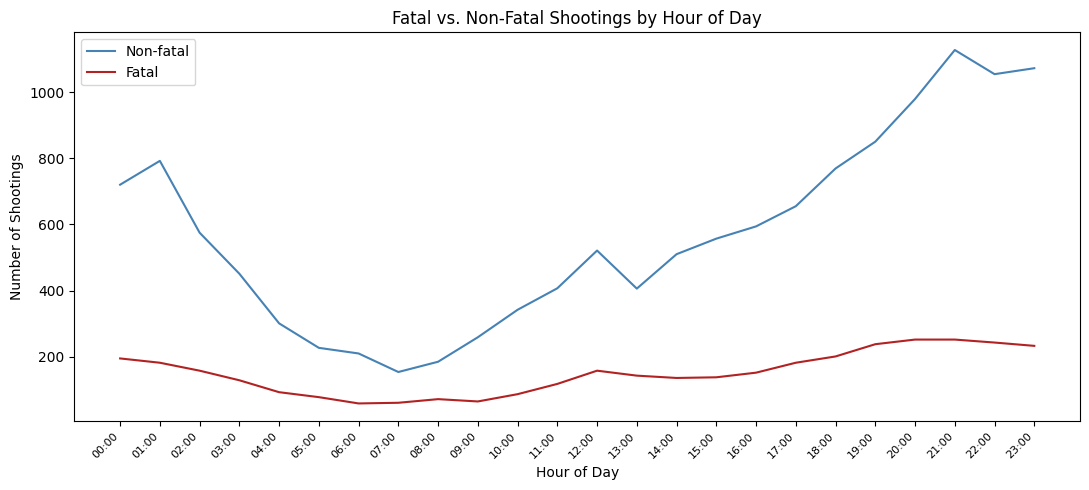

In [21]:
hourly_fatal = shootings_df[shootings_df['fatal']==1].groupby('hour').size()
hourly_nonfatal = shootings_df[shootings_df['fatal']==0].groupby('hour').size()
hours = list(range(24))

plt.figure(figsize=(11, 5))
plt.plot(hours, [hourly_nonfatal.get(h, 0) for h in hours], label='Non-fatal', color='steelblue')
plt.plot(hours, [hourly_fatal.get(h, 0) for h in hours], label='Fatal', color='firebrick')
plt.title('Fatal vs. Non-Fatal Shootings by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Shootings')
plt.xticks(hours, [f'{h:02d}:00' for h in hours], rotation=45, ha='right', fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

The above chart now shows the total number of fatal and non-fatal shootings across Philadelphia by time. It can be observed that during night time, although the number of shootings increases significantly, most of those are non-fatal. By analysing the ratio between non-fatal and fatal shootings across the day, it can be seen that the ratio is significantly smaller during early daytime hours. This could imply that shootings in the daytime, although fewer in number are more deliberate and intended to be fatal.

### Conclusion

As such, we can conclude that most of the shootings occur in warmer months when the sun is down. As such, it would be best to avoid dangerous areas during those times.